<a href="https://colab.research.google.com/github/raajuuu1998/ovarian-cancer-mil-benchmark/blob/main/Building_Multi_Instance_Learning_for_WSI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE         = "/content/drive/MyDrive/ovarian_mil"
SLIDES_DIR   = f"{BASE}/slides"
PATCHES_DIR  = f"{BASE}/patches"
FEATURES_DIR = f"{BASE}/features"
MODELS_DIR   = f"{BASE}/models"
RESULTS_DIR  = f"{BASE}/results"

for d in [SLIDES_DIR, PATCHES_DIR, FEATURES_DIR, MODELS_DIR, RESULTS_DIR,
          f"{FEATURES_DIR}/uni2", f"{FEATURES_DIR}/virchow2", f"{FEATURES_DIR}/phikon"]:
    os.makedirs(d, exist_ok=True)

print(" Drive mounted")
print(f" Project root: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted
 Project root: /content/drive/MyDrive/ovarian_mil


In [ ]:
import os, json, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

creds = json.load(open("/root/.kaggle/kaggle.json"))
os.environ["KAGGLE_USERNAME"] = creds["username"]
os.environ["KAGGLE_KEY"] = creds["key"]
print(" Kaggle auth ready")
print("Username:", creds["username"])

 Kaggle auth ready
Username: rajuuu1998


In [ ]:
import os, time

os.system("kaggle competitions download -c UBC-OCEAN -f train.csv -p /content/")

ids = [44603, 41368, 29084, 37385, 8280, 4134, 13568, 36783, 36583, 42857,
       61797, 57696, 36302, 50932, 53655, 41586, 21020, 48734, 40864, 35565,
       17637, 31594, 9200, 47035, 91]

for i, img_id in enumerate(ids):
    out_path = f"{SLIDES_DIR}/{img_id}.png"
    if os.path.exists(out_path):
        print(f"[{i+1}/25] {img_id} already in Drive ")
        continue
    print(f"[{i+1}/25] Downloading {img_id}...")
    os.system(f"kaggle competitions download -c UBC-OCEAN -f train_images/{img_id}.png -p {SLIDES_DIR}/")
    time.sleep(0.5)

nested = f"{SLIDES_DIR}/train_images"
if os.path.exists(nested):
    for f in os.listdir(nested):
        os.rename(f"{nested}/{f}", f"{SLIDES_DIR}/{f}")
    os.rmdir(nested)

files = [f for f in os.listdir(SLIDES_DIR) if f.endswith(".png")]
print(f"\n {len(files)}/25 slides in Drive")

[1/25] 44603 already in Drive 
[2/25] 41368 already in Drive 
[3/25] 29084 already in Drive 
[4/25] 37385 already in Drive 
[5/25] 8280 already in Drive 
[6/25] 4134 already in Drive 
[7/25] 13568 already in Drive 
[8/25] 36783 already in Drive 
[9/25] 36583 already in Drive 
[10/25] 42857 already in Drive 
[11/25] 61797 already in Drive 
[12/25] 57696 already in Drive 
[13/25] 36302 already in Drive 
[14/25] 50932 already in Drive 
[15/25] 53655 already in Drive 
[16/25] 41586 already in Drive 
[17/25] 21020 already in Drive 
[18/25] 48734 already in Drive 
[19/25] 40864 already in Drive 
[20/25] 35565 already in Drive 
[21/25] 17637 already in Drive 
[22/25] 31594 already in Drive 
[23/25] 9200 already in Drive 
[24/25] 47035 already in Drive 
[25/25] 91 already in Drive 

 25/25 slides in Drive


In [ ]:
import numpy as np, cv2, pandas as pd
from PIL import Image

id_to_label = {
    44603:'CC', 41368:'EC', 29084:'LGSC', 37385:'LGSC', 8280:'HGSC',
    4134:'MC',  13568:'LGSC', 36783:'MC', 36583:'LGSC', 42857:'CC',
    61797:'HGSC', 57696:'CC', 36302:'CC', 50932:'HGSC', 53655:'EC',
    41586:'CC', 21020:'MC',  48734:'EC', 40864:'LGSC', 35565:'MC',
    17637:'HGSC', 31594:'EC', 9200:'MC', 47035:'EC', 91:'HGSC'
}
LABEL2IDX   = {'CC':0, 'EC':1, 'HGSC':2, 'LGSC':3, 'MC':4}
PATCH_SIZE  = 224
MAX_PATCHES = 50
records     = []

for fname in sorted(os.listdir(SLIDES_DIR)):
    if not fname.endswith(".png"):
        continue
    img_id          = int(fname.replace(".png",""))
    label           = id_to_label[img_id]
    slide_patch_dir = os.path.join(PATCHES_DIR, str(img_id))

    if os.path.exists(slide_patch_dir) and len(os.listdir(slide_patch_dir)) > 0:
        n = len(os.listdir(slide_patch_dir))
        print(f"{fname:25s} | {label} | already tiled: {n} patches")
        for f in os.listdir(slide_patch_dir):
            records.append({"image_id": img_id, "label": label,
                            "patch": os.path.join(slide_patch_dir, f)})
        continue

    os.makedirs(slide_patch_dir, exist_ok=True)
    img  = np.array(Image.open(os.path.join(SLIDES_DIR, fname)).convert("RGB"))
    H, W = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    coords = []
    for y in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for x in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ratio = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum() / (PATCH_SIZE*PATCH_SIZE*255)
            if ratio > 0.5:
                coords.append((x, y))

    np.random.seed(42)
    if len(coords) > MAX_PATCHES:
        coords = [coords[i] for i in np.random.choice(len(coords), MAX_PATCHES, replace=False)]

    for i, (x, y) in enumerate(coords):
        patch  = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        p_path = os.path.join(slide_patch_dir, f"patch_{i}.png")
        Image.fromarray(patch).save(p_path)
        records.append({"image_id": img_id, "label": label, "patch": p_path})

    print(f"{fname:25s} | {label} | {len(coords)} patches")

df_patches = pd.DataFrame(records)
df_patches.to_csv(f"{BASE}/patches_index.csv", index=False)
print(f"\n Total patches: {len(df_patches)}")
print(df_patches.groupby('label').size())

13568.png                 | LGSC | already tiled: 50 patches
17637.png                 | HGSC | already tiled: 50 patches
21020.png                 | MC | already tiled: 50 patches
29084.png                 | LGSC | already tiled: 50 patches
31594.png                 | EC | already tiled: 50 patches
35565.png                 | MC | already tiled: 33 patches
36302.png                 | CC | already tiled: 50 patches
36583.png                 | LGSC | already tiled: 50 patches
36783.png                 | MC | already tiled: 20 patches
37385.png                 | LGSC | already tiled: 50 patches
40864.png                 | LGSC | already tiled: 50 patches
4134.png                  | MC | already tiled: 50 patches
41368.png                 | EC | already tiled: 50 patches
41586.png                 | CC | already tiled: 46 patches
42857.png                 | CC | already tiled: 50 patches
44603.png                 | CC | already tiled: 50 patches
47035.png                 | EC | already til

In [ ]:
import os

print(f"SLIDES_DIR: {SLIDES_DIR}")
print(f"Total files: {len(os.listdir(SLIDES_DIR))}")
print("\nAll files:")
for f in sorted(os.listdir(SLIDES_DIR)):
    size = os.path.getsize(os.path.join(SLIDES_DIR, f)) / (1024*1024)
    print(f"  {f:30s} {size:.1f} MB")

SLIDES_DIR: /content/drive/MyDrive/ovarian_mil/slides
Total files: 25

All files:
  13568.png                      14.0 MB
  17637.png                      14.5 MB
  21020.png                      17.5 MB
  29084.png                      17.0 MB
  31594.png                      17.1 MB
  35565.png                      13.5 MB
  36302.png                      18.5 MB
  36583.png                      17.5 MB
  36783.png                      12.8 MB
  37385.png                      16.6 MB
  40864.png                      13.9 MB
  4134.png                       13.5 MB
  41368.png                      17.7 MB
  41586.png                      14.0 MB
  42857.png                      13.9 MB
  44603.png                      18.4 MB
  47035.png                      13.9 MB
  48734.png                      18.6 MB
  50932.png                      13.8 MB
  53655.png                      17.1 MB
  57696.png                      17.5 MB
  61797.png                      18.1 MB
  8280.png      

In [ ]:
import zipfile, os

for fname in sorted(os.listdir(SLIDES_DIR)):
    if fname.endswith(".zip"):
        zip_path = os.path.join(SLIDES_DIR, fname)
        print(f"Unzipping {fname}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(SLIDES_DIR)
        os.remove(zip_path)

pngs = [f for f in os.listdir(SLIDES_DIR) if f.endswith(".png")]
print(f"\n {len(pngs)}/25 PNGs ready")


 25/25 PNGs ready


In [ ]:
import numpy as np, cv2, pandas as pd
from PIL import Image

id_to_label = {
    44603:'CC', 41368:'EC', 29084:'LGSC', 37385:'LGSC', 8280:'HGSC',
    4134:'MC',  13568:'LGSC', 36783:'MC', 36583:'LGSC', 42857:'CC',
    61797:'HGSC', 57696:'CC', 36302:'CC', 50932:'HGSC', 53655:'EC',
    41586:'CC', 21020:'MC',  48734:'EC', 40864:'LGSC', 35565:'MC',
    17637:'HGSC', 31594:'EC', 9200:'MC', 47035:'EC', 91:'HGSC'
}
LABEL2IDX   = {'CC':0, 'EC':1, 'HGSC':2, 'LGSC':3, 'MC':4}
PATCH_SIZE  = 224
MAX_PATCHES = 50
records     = []

for fname in sorted(os.listdir(SLIDES_DIR)):
    if not fname.endswith(".png"):
        continue
    img_id          = int(fname.replace(".png",""))
    label           = id_to_label[img_id]
    slide_patch_dir = os.path.join(PATCHES_DIR, str(img_id))

    if os.path.exists(slide_patch_dir) and len(os.listdir(slide_patch_dir)) > 0:
        n = len(os.listdir(slide_patch_dir))
        print(f"{fname:25s} | {label} | already tiled: {n} patches ")
        for f in sorted(os.listdir(slide_patch_dir)):
            records.append({"image_id": img_id, "label": label,
                            "patch": os.path.join(slide_patch_dir, f)})
        continue

    os.makedirs(slide_patch_dir, exist_ok=True)
    img  = np.array(Image.open(os.path.join(SLIDES_DIR, fname)).convert("RGB"))
    H, W = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    coords = []
    for y in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for x in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ratio = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum() / (PATCH_SIZE*PATCH_SIZE*255)
            if ratio > 0.5:
                coords.append((x, y))

    np.random.seed(42)
    if len(coords) > MAX_PATCHES:
        coords = [coords[i] for i in np.random.choice(len(coords), MAX_PATCHES, replace=False)]

    for i, (x, y) in enumerate(coords):
        patch  = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        p_path = os.path.join(slide_patch_dir, f"patch_{i}.png")
        Image.fromarray(patch).save(p_path)
        records.append({"image_id": img_id, "label": label, "patch": p_path})

    print(f"{fname:25s} | {label} | {len(coords)} patches ")

df_patches = pd.DataFrame(records)
df_patches.to_csv(f"{BASE}/patches_index.csv", index=False)
print(f"\n Total patches: {len(df_patches)}")
print(df_patches.groupby('label').size())

13568.png                 | LGSC | already tiled: 50 patches 
17637.png                 | HGSC | already tiled: 50 patches 
21020.png                 | MC | already tiled: 50 patches 
29084.png                 | LGSC | already tiled: 50 patches 
31594.png                 | EC | already tiled: 50 patches 
35565.png                 | MC | already tiled: 33 patches 
36302.png                 | CC | already tiled: 50 patches 
36583.png                 | LGSC | already tiled: 50 patches 
36783.png                 | MC | already tiled: 20 patches 
37385.png                 | LGSC | already tiled: 50 patches 
40864.png                 | LGSC | already tiled: 50 patches 
4134.png                  | MC | already tiled: 50 patches 
41368.png                 | EC | already tiled: 50 patches 
41586.png                 | CC | already tiled: 46 patches 
42857.png                 | CC | already tiled: 50 patches 
44603.png                 | CC | already tiled: 50 patches 
47035.png                 | 

In [ ]:
!pip install -q timm huggingface_hub einops transformers
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os, torch, numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from timm.layers import SwiGLUPacked

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

id_to_label = {
    44603:'CC', 41368:'EC', 29084:'LGSC', 37385:'LGSC', 8280:'HGSC',
    4134:'MC',  13568:'LGSC', 36783:'MC', 36583:'LGSC', 42857:'CC',
    61797:'HGSC', 57696:'CC', 36302:'CC', 50932:'HGSC', 53655:'EC',
    41586:'CC', 21020:'MC',  48734:'EC', 40864:'LGSC', 35565:'MC',
    17637:'HGSC', 31594:'EC', 9200:'MC', 47035:'EC', 91:'HGSC'
}
LABEL2IDX = {'CC':0, 'EC':1, 'HGSC':2, 'LGSC':3, 'MC':4}

class PatchDataset(Dataset):
    def __init__(self, patch_paths, transform):
        self.paths = patch_paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert("RGB"))

print("\nLoading UNI2-h...")
timm_kwargs = {
    'img_size': 224, 'patch_size': 14, 'depth': 24,
    'num_heads': 24, 'init_values': 1e-5, 'embed_dim': 1536,
    'mlp_ratio': 2.66667*2, 'num_classes': 0,
    'no_embed_class': True, 'mlp_layer': SwiGLUPacked,
    'act_layer': torch.nn.SiLU, 'reg_tokens': 8,
    'dynamic_img_size': True
}
uni2 = timm.create_model("hf-hub:MahmoodLab/UNI2-h", pretrained=True, **timm_kwargs)
transform = create_transform(**resolve_data_config(uni2.pretrained_cfg, model=uni2))
uni2 = uni2.to(DEVICE)
uni2.eval()
print("UNI2 loaded ")

out_dir = f"{FEATURES_DIR}/uni2"
os.makedirs(out_dir, exist_ok=True)

for slide_id in sorted(os.listdir(PATCHES_DIR)):
    out_path = os.path.join(out_dir, f"{slide_id}.pt")
    if os.path.exists(out_path):
        print(f"  {slide_id} already done ")
        continue

    patch_dir   = os.path.join(PATCHES_DIR, slide_id)
    patch_paths = sorted([os.path.join(patch_dir, f)
                          for f in os.listdir(patch_dir) if f.endswith(".png")])

    loader = DataLoader(PatchDataset(patch_paths, transform),
                        batch_size=32, num_workers=2,
                        pin_memory=(DEVICE=="cuda"))
    feats = []
    with torch.no_grad():
        for batch in loader:
            emb = uni2(batch.to(DEVICE))
            if emb.ndim == 3:
                emb = emb.mean(dim=1)
            feats.append(emb.cpu())

    feats = torch.cat(feats, dim=0)
    label = id_to_label[int(slide_id)]
    torch.save({"features": feats, "label": label,
                "label_idx": LABEL2IDX[label], "slide_id": slide_id}, out_path)
    print(f"  {slide_id:8s} | {label} | {feats.shape} ")

del uni2; torch.cuda.empty_cache()
print("\n UNI2 extraction done")

Device: cuda
GPU: NVIDIA L4

Loading UNI2-h...


config.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.73G [00:00<?, ?B/s]

UNI2 loaded 
  13568 already done 
  17637 already done 
  21020 already done 
  29084 already done 
  31594 already done 
  35565 already done 
  36302 already done 
  36583 already done 
  36783 already done 
  37385 already done 
  40864 already done 
  4134 already done 
  41368 already done 
  41586 already done 
  42857 already done 
  44603 already done 
  47035 already done 
  48734 already done 
  50932 already done 
  53655 already done 
  57696 already done 
  61797 already done 
  8280 already done 
  91 already done 
  9200 already done 

 UNI2 extraction done


In [ ]:
from timm.layers import SwiGLUPacked

print("Loading Virchow2...")
virchow2 = timm.create_model(
    "hf-hub:paige-ai/Virchow2", pretrained=True,
    mlp_layer=SwiGLUPacked, act_layer=torch.nn.SiLU,
)
v2_transform = create_transform(**resolve_data_config(virchow2.pretrained_cfg, model=virchow2))
virchow2 = virchow2.to(DEVICE)
virchow2.eval()
print("Virchow2 loaded ")

out_dir = f"{FEATURES_DIR}/virchow2"
os.makedirs(out_dir, exist_ok=True)

for slide_id in sorted(os.listdir(PATCHES_DIR)):
    out_path = os.path.join(out_dir, f"{slide_id}.pt")
    if os.path.exists(out_path):
        print(f"  {slide_id} already done ")
        continue

    patch_dir   = os.path.join(PATCHES_DIR, slide_id)
    patch_paths = sorted([os.path.join(patch_dir, f)
                          for f in os.listdir(patch_dir) if f.endswith(".png")])

    loader = DataLoader(PatchDataset(patch_paths, v2_transform),
                        batch_size=32, num_workers=2,
                        pin_memory=True)
    feats = []
    with torch.no_grad():
        for batch in loader:
            out = virchow2(batch.to(DEVICE))
            class_token = out[:, 0, :]
            patch_tokens = out[:, 1:, :].mean(dim=1)
            emb = torch.cat([class_token, patch_tokens], dim=-1)
            feats.append(emb.cpu())

    feats = torch.cat(feats, dim=0)
    label = id_to_label[int(slide_id)]
    torch.save({"features": feats, "label": label,
                "label_idx": LABEL2IDX[label], "slide_id": slide_id}, out_path)
    print(f"  {slide_id:8s} | {label} | {feats.shape} ")

del virchow2; torch.cuda.empty_cache()
print("\n Virchow2 extraction done")

Loading Virchow2...


config.json:   0%|          | 0.00/742 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

Virchow2 loaded 
  13568 already done 
  17637 already done 
  21020 already done 
  29084 already done 
  31594 already done 
  35565 already done 
  36302 already done 
  36583 already done 
  36783 already done 
  37385 already done 
  40864 already done 
  4134 already done 
  41368 already done 
  41586 already done 
  42857 already done 
  44603 already done 
  47035 already done 
  48734 already done 
  50932 already done 
  53655 already done 
  57696 already done 
  61797 already done 
  8280 already done 
  91 already done 
  9200 already done 

 Virchow2 extraction done


In [ ]:
from transformers import AutoImageProcessor, AutoModel

print("Loading Phikon...")
processor = AutoImageProcessor.from_pretrained("owkin/phikon")
phikon = AutoModel.from_pretrained("owkin/phikon").to(DEVICE)
phikon.eval()
print("Phikon loaded ")

out_dir = f"{FEATURES_DIR}/phikon"
os.makedirs(out_dir, exist_ok=True)

for slide_id in sorted(os.listdir(PATCHES_DIR)):
    out_path = os.path.join(out_dir, f"{slide_id}.pt")
    if os.path.exists(out_path):
        print(f"  {slide_id} already done ")
        continue

    patch_dir   = os.path.join(PATCHES_DIR, slide_id)
    patch_paths = sorted([os.path.join(patch_dir, f)
                          for f in os.listdir(patch_dir) if f.endswith(".png")])

    feats = []
    with torch.no_grad():
        for i in range(0, len(patch_paths), 32):
            batch_imgs = [Image.open(p).convert("RGB")
                          for p in patch_paths[i:i+32]]
            inputs = processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
            out    = phikon(**inputs)
            emb    = out.last_hidden_state[:, 0, :]
            feats.append(emb.cpu())

    feats = torch.cat(feats, dim=0)
    label = id_to_label[int(slide_id)]
    torch.save({"features": feats, "label": label,
                "label_idx": LABEL2IDX[label], "slide_id": slide_id}, out_path)
    print(f"  {slide_id:8s} | {label} | {feats.shape} ")

del phikon; torch.cuda.empty_cache()
print("\n Phikon extraction done")

Loading Phikon...


preprocessor_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Phikon loaded 
  13568 already done 
  17637 already done 
  21020 already done 
  29084 already done 
  31594 already done 
  35565 already done 
  36302 already done 
  36583 already done 
  36783 already done 
  37385 already done 
  40864 already done 
  4134 already done 
  41368 already done 
  41586 already done 
  42857 already done 
  44603 already done 
  47035 already done 
  48734 already done 
  50932 already done 
  53655 already done 
  57696 already done 
  61797 already done 
  8280 already done 
  91 already done 
  9200 already done 

 Phikon extraction done


In [ ]:
# CELL 9 — All MIL Models (FINAL)
import torch
import torch.nn as nn
import random, numpy as np, os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)

set_seed(42)
print(" Seed fixed")

# ── 1. MeanMIL ───────────────────────────────────────────────
class MeanMIL(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.fc(x.mean(dim=0, keepdim=True))

# ── 2. MaxMIL ────────────────────────────────────────────────
class MaxMIL(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.fc(x.max(dim=0, keepdim=True).values)

# ── 3. ABMIL ─────────────────────────────────────────────────
class ABMIL(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU())
        self.attn = nn.Sequential(
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.fc = nn.Linear(256, n_classes)

    def forward(self, x):
        h = self.proj(x)
        a = torch.softmax(self.attn(h), dim=0)
        z = (a * h).sum(dim=0, keepdim=True)
        return self.fc(z)

# ── 4. CLAM ──────────────────────────────────────────────────
class CLAM(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj   = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU())
        self.attn_V = nn.Sequential(nn.Linear(256, 128), nn.Tanh())
        self.attn_U = nn.Sequential(nn.Linear(256, 128), nn.Sigmoid())
        self.attn_w = nn.Linear(128, 1)
        self.fc     = nn.Linear(256, n_classes)

    def forward(self, x):
        h = self.proj(x)
        a = torch.softmax(self.attn_w(self.attn_V(h) * self.attn_U(h)), dim=0)
        z = (a * h).sum(dim=0, keepdim=True)
        return self.fc(z)

# ── 5. DSMIL ─────────────────────────────────────────────────
class DSMIL(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj    = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU())
        self.attn    = nn.Linear(256, 1)
        self.fc_max  = nn.Linear(256, n_classes)
        self.fc_attn = nn.Linear(256, n_classes)

    def forward(self, x):
        h          = self.proj(x)
        logits_max = self.fc_max(h)
        crit_idx   = logits_max.max(dim=-1).values.argmax()
        crit       = h[crit_idx].unsqueeze(0)
        a          = torch.softmax(self.attn(h), dim=0)
        z          = (a * h).sum(dim=0, keepdim=True)
        return self.fc_attn(z) + self.fc_max(crit)

# ── 6. TransMILv2 (FIXED) ────────────────────────────────────
class TransMILv2(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256)
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cls_token   = nn.Parameter(torch.randn(1, 1, 256) * 0.02)
        self.fc          = nn.Linear(256, n_classes)

    def forward(self, x):
        h   = self.proj(x).unsqueeze(0)
        cls = self.cls_token.expand(1, -1, -1)
        h   = torch.cat([cls, h], dim=1)
        h   = self.transformer(h)
        return self.fc(h[:, 0, :])

# ── 7. GT-MILv2 (FIXED — the one that got 0.920) ─────────────
class GTMILv2(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU()
        )
        self.gate = nn.Sequential(
            nn.Linear(256, 64), nn.Tanh(),
            nn.Linear(64, 1),   nn.Sigmoid()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cls_token   = nn.Parameter(torch.randn(1, 1, 256) * 0.02)
        self.fc = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        h     = self.proj(x)
        gates = self.gate(h)
        h     = h * gates
        h     = h.unsqueeze(0)
        cls   = self.cls_token.expand(1, -1, -1)
        h     = torch.cat([cls, h], dim=1)
        h     = self.transformer(h)
        return self.fc(h[:, 0, :])

print(" All 7 MIL models defined")
print("   1. MeanMIL")
print("   2. MaxMIL")
print("   3. ABMIL")
print("   4. CLAM")
print("   5. DSMIL")
print("   6. TransMILv2 ")
print("   7. GT-MILv2 ")

 Seed fixed
 All 7 MIL models defined
   1. MeanMIL
   2. MaxMIL
   3. ABMIL
   4. CLAM
   5. DSMIL
   6. TransMILv2 
   7. GT-MILv2 


In [ ]:
# CELL 10 — Training + Evaluation (LOOCV) FINAL
import os, torch, numpy as np
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import pandas as pd

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
LABEL2IDX = {'CC':0, 'EC':1, 'HGSC':2, 'LGSC':3, 'MC':4}
IDX2LABEL = {v:k for k,v in LABEL2IDX.items()}
N_CLASSES = 5
EPOCHS    = 150

# ── Load features ─────────────────────────────────────────────
def load_bags(backbone):
    bags, labels, slide_ids = [], [], []
    feat_dir = os.path.join(FEATURES_DIR, backbone)
    for fname in sorted(os.listdir(feat_dir)):
        data = torch.load(os.path.join(feat_dir, fname))
        bags.append(data["features"].float())
        labels.append(data["label_idx"])
        slide_ids.append(data["slide_id"])
    return bags, labels, slide_ids

# ── Normalize ─────────────────────────────────────────────────
def normalize_bags(bags):
    all_feats = torch.cat(bags, dim=0)
    mean = all_feats.mean(dim=0, keepdim=True)
    std  = all_feats.std(dim=0,  keepdim=True) + 1e-6
    return [(b - mean) / std for b in bags], mean, std

# ── Train one fold ────────────────────────────────────────────
def train_fold(model, train_bags, train_labels, epochs=EPOCHS):
    set_seed(42)  # ← fixed seed every fold
    model.train()
    optimizer = Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    for epoch in range(epochs):
        idx = np.random.permutation(len(train_bags))
        for i in idx:
            x = train_bags[i].to(DEVICE)
            y = torch.tensor([train_labels[i]], dtype=torch.long).to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
    return model

# ── LOOCV ─────────────────────────────────────────────────────
def run_loocv(model_class, bags, labels, slide_ids, in_dim):
    set_seed(42)  # ← fixed seed before full run
    all_preds, all_true = [], []

    for i in range(len(bags)):
        train_bags   = [bags[j]   for j in range(len(bags))   if j != i]
        train_labels = [labels[j] for j in range(len(labels)) if j != i]

        norm_train, mean, std = normalize_bags(train_bags)
        norm_test = (bags[i] - mean) / std

        model = model_class(in_dim=in_dim, n_classes=N_CLASSES).to(DEVICE)
        model = train_fold(model, norm_train, train_labels)

        model.eval()
        with torch.no_grad():
            logits = model(norm_test.to(DEVICE))
            pred   = logits.argmax(dim=-1).item()

        all_preds.append(pred)
        all_true.append(labels[i])

    bal_acc = balanced_accuracy_score(all_true, all_preds)
    f1      = f1_score(all_true, all_preds, average='weighted', zero_division=0)
    cm      = confusion_matrix(all_true, all_preds, labels=list(range(N_CLASSES)))
    return bal_acc, f1, cm, all_preds, all_true

# ── Run all 21 combinations ───────────────────────────────────
backbones = {
    "UNI2":     ("uni2",     1536),
    "Virchow2": ("virchow2", 2560),
    "Phikon":   ("phikon",   768),
}

mil_models = {
    "MeanMIL":    MeanMIL,
    "MaxMIL":     MaxMIL,
    "ABMIL":      ABMIL,
    "CLAM":       CLAM,
    "DSMIL":      DSMIL,
    "TransMILv2": TransMILv2,
    "GT-MILv2":   GTMILv2,
}

results = []

for bb_name, (bb_key, in_dim) in backbones.items():
    print(f"\n{'='*55}")
    print(f"  Backbone: {bb_name}  (dim={in_dim})")
    print(f"{'='*55}")

    bags, labels, slide_ids = load_bags(bb_key)

    for mil_name, mil_class in mil_models.items():
        print(f"  Running {mil_name}...", end=" ", flush=True)
        bal_acc, f1, cm, preds, trues = run_loocv(
            mil_class, bags, labels, slide_ids, in_dim
        )
        print(f"BalAcc={bal_acc:.3f}  F1={f1:.3f}")
        results.append({
            "Backbone":  bb_name,
            "MIL Model": mil_name,
            "Bal Acc":   round(bal_acc, 3),
            "F1":        round(f1, 3),
        })

# ── Results Table ─────────────────────────────────────────────
df = pd.DataFrame(results)
df.to_csv(f"{RESULTS_DIR}/results_final.csv", index=False)

pivot_acc = df.pivot(index="MIL Model", columns="Backbone", values="Bal Acc")
pivot_f1  = df.pivot(index="MIL Model", columns="Backbone", values="F1")

print("\n\n BALANCED ACCURACY")
print(pivot_acc.to_string())
print("\n WEIGHTED F1")
print(pivot_f1.to_string())
print(f"\n Results saved to Drive")


  Backbone: UNI2  (dim=1536)
  Running MeanMIL... BalAcc=0.880  F1=0.880
  Running MaxMIL... BalAcc=0.840  F1=0.837
  Running ABMIL... BalAcc=0.880  F1=0.883
  Running CLAM... BalAcc=0.880  F1=0.880
  Running DSMIL... BalAcc=0.800  F1=0.779
  Running TransMILv2... 

/tmp/ipykernel_10195/1464590855.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


BalAcc=0.880  F1=0.880
  Running GT-MILv2... 

/tmp/ipykernel_10195/1464590855.py:131: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


BalAcc=0.920  F1=0.920

  Backbone: Virchow2  (dim=2560)
  Running MeanMIL... BalAcc=0.720  F1=0.731
  Running MaxMIL... BalAcc=0.720  F1=0.713
  Running ABMIL... BalAcc=0.800  F1=0.803
  Running CLAM... BalAcc=0.760  F1=0.770
  Running DSMIL... BalAcc=0.760  F1=0.769
  Running TransMILv2... 

...

BalAcc=0.760  F1=0.764

  Backbone: Phikon  (dim=768)
  Running MeanMIL... BalAcc=0.760  F1=0.766
  Running MaxMIL... BalAcc=0.680  F1=0.679
  Running ABMIL... BalAcc=0.800  F1=0.803
  Running CLAM... BalAcc=0.800  F1=0.803
  Running DSMIL... BalAcc=0.560  F1=0.551
  Running TransMILv2... 

/tmp/ipykernel_10195/1464590855.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


BalAcc=0.800  F1=0.801
  Running GT-MILv2... 

/tmp/ipykernel_10195/1464590855.py:131: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


BalAcc=0.760  F1=0.754


 BALANCED ACCURACY
Backbone    Phikon  UNI2  Virchow2
MIL Model                         
ABMIL         0.80  0.88      0.80
CLAM          0.80  0.88      0.76
DSMIL         0.56  0.80      0.76
GT-MILv2      0.76  0.92      0.76
MaxMIL        0.68  0.84      0.72
MeanMIL       0.76  0.88      0.72
TransMILv2    0.80  0.88      0.72

 WEIGHTED F1
Backbone    Phikon   UNI2  Virchow2
MIL Model                          
ABMIL        0.803  0.883     0.803
CLAM         0.803  0.880     0.770
DSMIL        0.551  0.779     0.769
GT-MILv2     0.754  0.920     0.764
MaxMIL       0.679  0.837     0.713
MeanMIL      0.766  0.880     0.731
TransMILv2   0.801  0.880     0.720

 Results saved to Drive


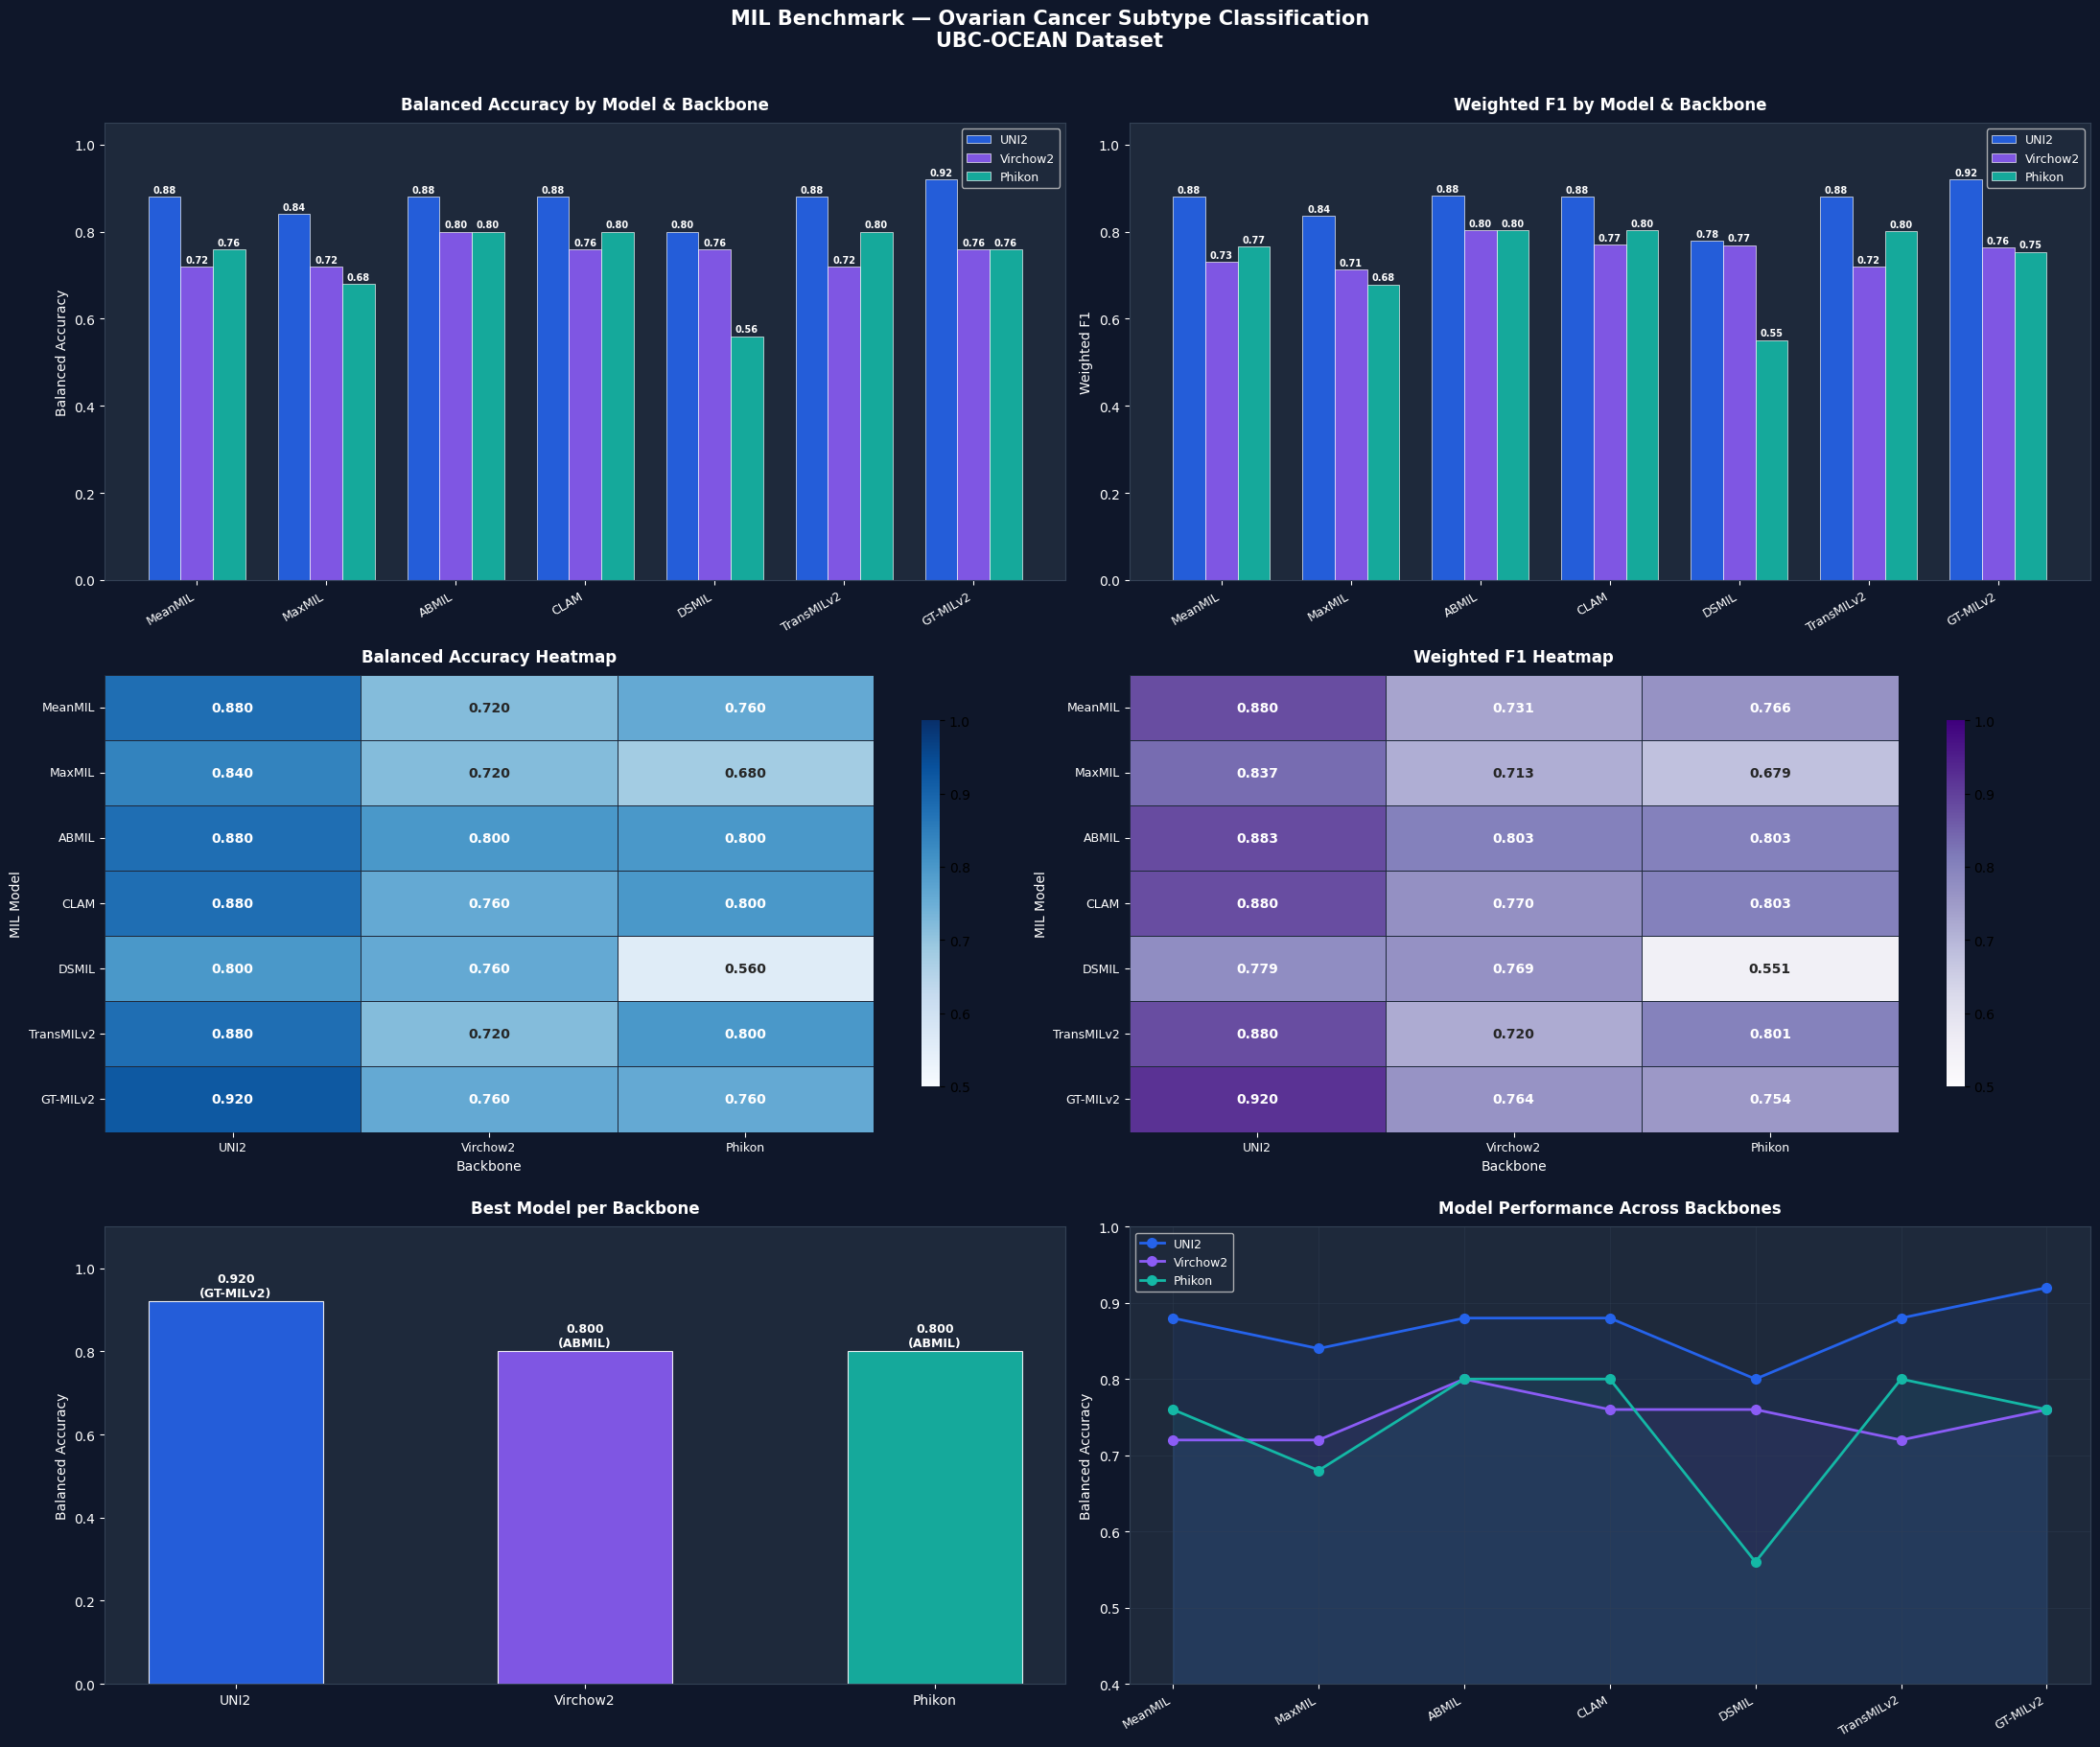

In [ ]:
# CELL 12 — Visualization (UPDATED SCORES)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Updated scores from latest run ───────────────────────────
data_acc = {
    "MeanMIL":    {"UNI2": 0.880, "Virchow2": 0.720, "Phikon": 0.760},
    "MaxMIL":     {"UNI2": 0.840, "Virchow2": 0.720, "Phikon": 0.680},
    "ABMIL":      {"UNI2": 0.880, "Virchow2": 0.800, "Phikon": 0.800},
    "CLAM":       {"UNI2": 0.880, "Virchow2": 0.760, "Phikon": 0.800},
    "DSMIL":      {"UNI2": 0.800, "Virchow2": 0.760, "Phikon": 0.560},
    "TransMILv2": {"UNI2": 0.880, "Virchow2": 0.720, "Phikon": 0.800},
    "GT-MILv2":   {"UNI2": 0.920, "Virchow2": 0.760, "Phikon": 0.760},
}

data_f1 = {
    "MeanMIL":    {"UNI2": 0.880, "Virchow2": 0.731, "Phikon": 0.766},
    "MaxMIL":     {"UNI2": 0.837, "Virchow2": 0.713, "Phikon": 0.679},
    "ABMIL":      {"UNI2": 0.883, "Virchow2": 0.803, "Phikon": 0.803},
    "CLAM":       {"UNI2": 0.880, "Virchow2": 0.770, "Phikon": 0.803},
    "DSMIL":      {"UNI2": 0.779, "Virchow2": 0.769, "Phikon": 0.551},
    "TransMILv2": {"UNI2": 0.880, "Virchow2": 0.720, "Phikon": 0.801},
    "GT-MILv2":   {"UNI2": 0.920, "Virchow2": 0.764, "Phikon": 0.754},
}

df_acc = pd.DataFrame(data_acc).T
df_f1  = pd.DataFrame(data_f1).T
models    = list(data_acc.keys())
backbones = ["UNI2", "Virchow2", "Phikon"]
colors    = {"UNI2": "#2563EB", "Virchow2": "#8B5CF6", "Phikon": "#14B8A6"}

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor("#0F172A")

# ── 1. Grouped Bar — Balanced Accuracy ───────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor("#1E293B")
x     = np.arange(len(models))
width = 0.25
for i, bb in enumerate(backbones):
    vals = [data_acc[m][bb] for m in models]
    bars = ax1.bar(x + i*width, vals, width, label=bb,
                   color=colors[bb], alpha=0.9, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.2f}", ha='center', va='bottom',
                 fontsize=7, color='white', fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models, rotation=30, ha='right', color='white', fontsize=9)
ax1.set_ylim(0, 1.05)
ax1.set_title("Balanced Accuracy by Model & Backbone",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel("Balanced Accuracy", color='white', fontsize=10)
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1E293B', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#334155')

# ── 2. Grouped Bar — Weighted F1 ─────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor("#1E293B")
for i, bb in enumerate(backbones):
    vals = [data_f1[m][bb] for m in models]
    bars = ax2.bar(x + i*width, vals, width, label=bb,
                   color=colors[bb], alpha=0.9, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.2f}", ha='center', va='bottom',
                 fontsize=7, color='white', fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(models, rotation=30, ha='right', color='white', fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.set_title("Weighted F1 by Model & Backbone",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel("Weighted F1", color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#1E293B', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#334155')

# ── 3. Heatmap — Balanced Accuracy ───────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor("#1E293B")
sns.heatmap(df_acc, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, linecolor="#1E293B",
            annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={"shrink": 0.8}, ax=ax3,
            vmin=0.5, vmax=1.0)
ax3.set_title("Balanced Accuracy Heatmap",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(colors='white', labelsize=9)
ax3.set_xlabel("Backbone", color='white', fontsize=10)
ax3.set_ylabel("MIL Model", color='white', fontsize=10)

# ── 4. Heatmap — Weighted F1 ─────────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor("#1E293B")
sns.heatmap(df_f1, annot=True, fmt=".3f", cmap="Purples",
            linewidths=0.5, linecolor="#1E293B",
            annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={"shrink": 0.8}, ax=ax4,
            vmin=0.5, vmax=1.0)
ax4.set_title("Weighted F1 Heatmap",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax4.tick_params(colors='white', labelsize=9)
ax4.set_xlabel("Backbone", color='white', fontsize=10)
ax4.set_ylabel("MIL Model", color='white', fontsize=10)

# ── 5. Best per backbone ──────────────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
ax5.set_facecolor("#1E293B")
best_per_bb = {bb: max([data_acc[m][bb] for m in models]) for bb in backbones}
best_model  = {bb: max(models, key=lambda m: data_acc[m][bb]) for bb in backbones}
bb_colors   = [colors[bb] for bb in backbones]
bars = ax5.bar(backbones, best_per_bb.values(), color=bb_colors,
               alpha=0.9, edgecolor='white', linewidth=0.8, width=0.5)
for bar, (bb, val) in zip(bars, best_per_bb.items()):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}\n({best_model[bb]})",
             ha='center', va='bottom', color='white',
             fontsize=9, fontweight='bold')
ax5.set_ylim(0, 1.1)
ax5.set_title("Best Model per Backbone",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax5.set_ylabel("Balanced Accuracy", color='white', fontsize=10)
ax5.tick_params(colors='white')
for spine in ax5.spines.values():
    spine.set_edgecolor('#334155')

# ── 6. Line — model consistency ──────────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
ax6.set_facecolor("#1E293B")
for bb in backbones:
    vals = [data_acc[m][bb] for m in models]
    ax6.plot(models, vals, marker='o', label=bb,
             color=colors[bb], linewidth=2, markersize=7)
    ax6.fill_between(range(len(models)), vals,
                     alpha=0.08, color=colors[bb])
ax6.set_xticks(range(len(models)))
ax6.set_xticklabels(models, rotation=30, ha='right', color='white', fontsize=9)
ax6.set_ylim(0.4, 1.0)
ax6.set_title("Model Performance Across Backbones",
              color='white', fontsize=12, fontweight='bold', pad=10)
ax6.set_ylabel("Balanced Accuracy", color='white', fontsize=10)
ax6.tick_params(colors='white')
ax6.legend(facecolor='#1E293B', labelcolor='white', fontsize=9)
ax6.grid(True, color='#334155', linewidth=0.5, alpha=0.5)
for spine in ax6.spines.values():
    spine.set_edgecolor('#334155')

plt.suptitle("MIL Benchmark — Ovarian Cancer Subtype Classification\nUBC-OCEAN Dataset",
             color='white', fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/benchmark_results.png",
            dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()


Training ABMIL on full data...
 ABMIL trained
Training GT-MILv2 on full data...


/tmp/ipykernel_10195/1646277332.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


 GT-MILv2 trained


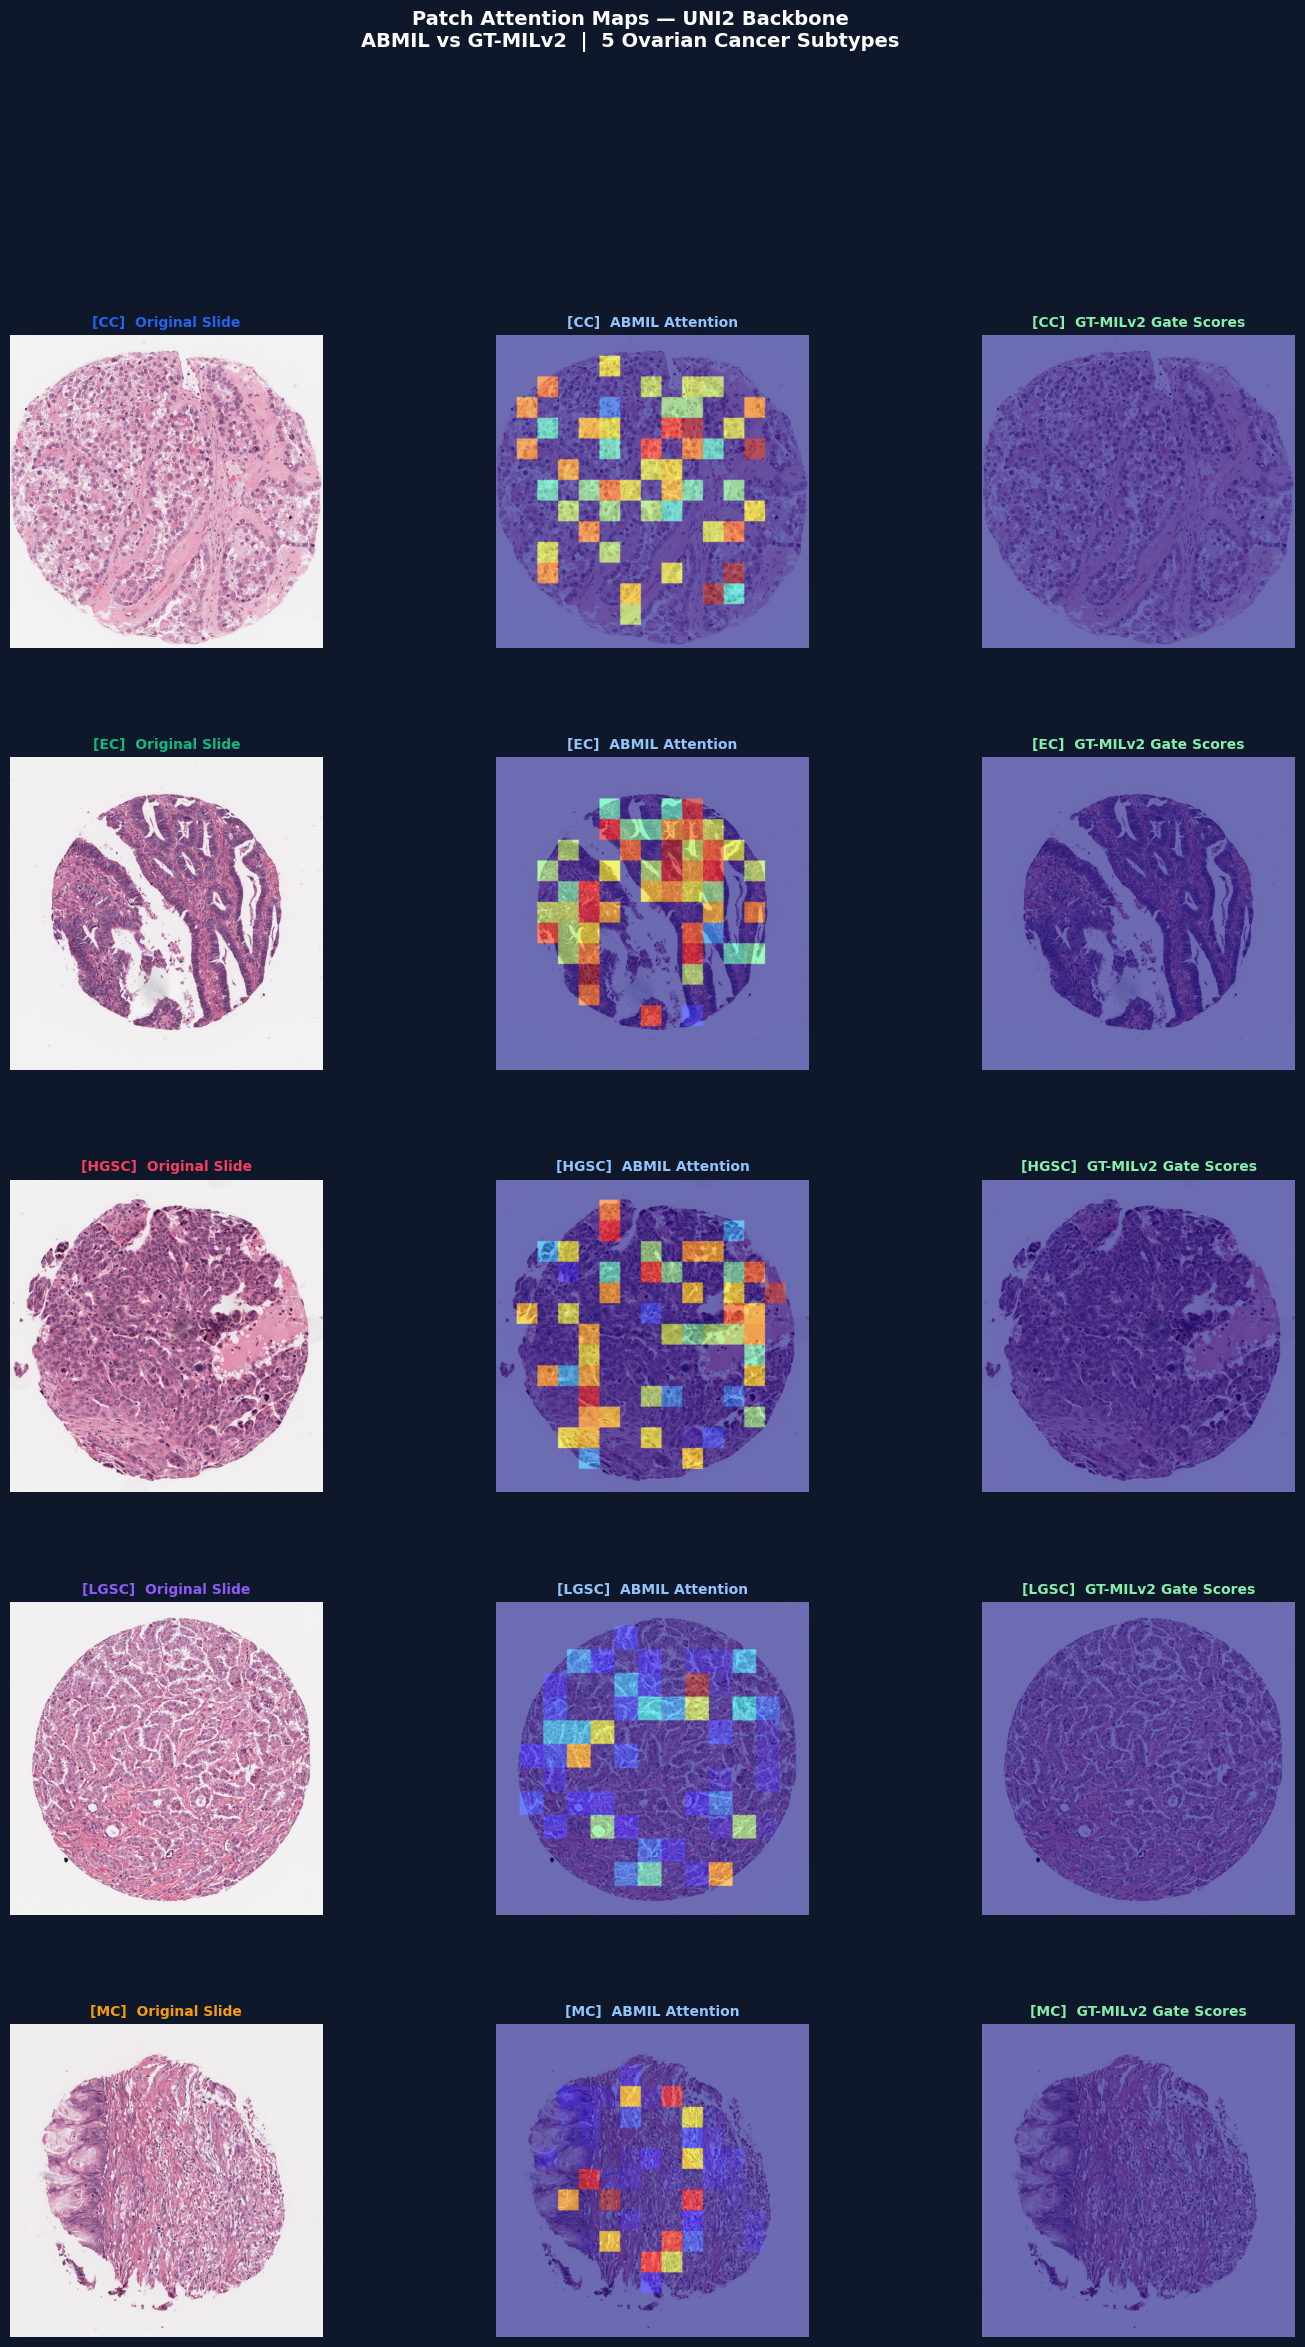

Attention maps saved to Drive


In [ ]:
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = 224

CLASS_SLIDES = {
    'CC':   '36302',
    'EC':   '31594',
    'HGSC': '61797',
    'LGSC': '13568',
    'MC':   '21020',
}
CLASS_COLORS = {
    'CC':   '#2563EB',
    'EC':   '#10B981',
    'HGSC': '#F43F5E',
    'LGSC': '#8B5CF6',
    'MC':   '#F59E0B',
}

class ABMILWithAttn(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU())
        self.attn = nn.Sequential(
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.fc = nn.Linear(256, n_classes)

    def forward(self, x):
        h      = self.proj(x)
        a      = torch.softmax(self.attn(h), dim=0)  # [N,1]
        z      = (a * h).sum(dim=0, keepdim=True)
        logits = self.fc(z)
        return logits, a.squeeze()                    # return attn weights

class GTMILv2WithAttn(nn.Module):
    def __init__(self, in_dim, n_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU()
        )
        self.gate = nn.Sequential(
            nn.Linear(256, 64), nn.Tanh(),
            nn.Linear(64, 1),   nn.Sigmoid()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cls_token   = nn.Parameter(torch.randn(1, 1, 256) * 0.02)
        self.fc = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        h      = self.proj(x)
        gates  = self.gate(h)               # [N, 1]
        h      = h * gates
        h      = h.unsqueeze(0)
        cls    = self.cls_token.expand(1, -1, -1)
        h      = torch.cat([cls, h], dim=1)
        h      = self.transformer(h)
        logits = self.fc(h[:, 0, :])
        return logits, gates.squeeze()      # return gate scores

def train_full(model_class, bags, labels, in_dim, epochs=150):
    set_seed(42)
    all_feats = torch.cat(bags, dim=0)
    mean = all_feats.mean(dim=0, keepdim=True)
    std  = all_feats.std(dim=0,  keepdim=True) + 1e-6
    norm_bags = [(b - mean) / std for b in bags]

    model     = model_class(in_dim=in_dim, n_classes=5).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    model.train()
    for epoch in range(epochs):
        idx = np.random.permutation(len(norm_bags))
        for i in idx:
            x = norm_bags[i].to(DEVICE)
            y = torch.tensor([labels[i]], dtype=torch.long).to(DEVICE)
            optimizer.zero_grad()
            out    = model(x)
            logits = out[0] if isinstance(out, tuple) else out
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

    return model, mean, std

def get_patch_coords(slide_id):
    import cv2
    img_path = os.path.join(SLIDES_DIR, f"{slide_id}.png")
    img      = np.array(Image.open(img_path).convert("RGB"))
    H, W     = img.shape[:2]
    gray     = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask  = cv2.threshold(gray, 0, 255,
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = []
    for y in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for x in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ratio = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum() / \
                    (PATCH_SIZE * PATCH_SIZE * 255)
            if ratio > 0.5:
                coords.append((x, y))
    np.random.seed(42)
    if len(coords) > 50:
        coords = [coords[i] for i in
                  np.random.choice(len(coords), 50, replace=False)]
    return img, coords, H, W

def make_real_attention_overlay(slide_id, attn_weights):
    img, coords, H, W = get_patch_coords(slide_id)
    attn_np = attn_weights.detach().cpu().numpy()
    attn_np = (attn_np - attn_np.min()) / \
              (attn_np.max() - attn_np.min() + 1e-6)
    attn_canvas = np.zeros((H, W), dtype=np.float32)
    for i, (x, y) in enumerate(coords[:len(attn_np)]):
        attn_canvas[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = attn_np[i]
    return img, attn_canvas

bags, labels, slide_ids = load_bags("uni2")

print("Training ABMIL on full data...")
abmil_model, abmil_mean, abmil_std = train_full(
    ABMILWithAttn, bags, labels, in_dim=1536)
print(" ABMIL trained")

print("Training GT-MILv2 on full data...")
gtmil_model, gtmil_mean, gtmil_std = train_full(
    GTMILv2WithAttn, bags, labels, in_dim=1536)
print(" GT-MILv2 trained")

CLASS_ORDER = ['CC', 'EC', 'HGSC', 'LGSC', 'MC']

fig = plt.figure(figsize=(18, 26))
fig.patch.set_facecolor("#0F172A")
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.35, wspace=0.15)

for row, cls in enumerate(CLASS_ORDER):
    slide_id  = CLASS_SLIDES[cls]
    slide_idx = slide_ids.index(slide_id)
    color     = CLASS_COLORS[cls]
    feats     = bags[slide_idx].float()

    # ABMIL
    norm_ab = (feats - abmil_mean) / (abmil_std + 1e-6)
    abmil_model.eval()
    with torch.no_grad():
        _, attn_ab = abmil_model(norm_ab.to(DEVICE))

    # GT-MILv2
    norm_gt = (feats - gtmil_mean) / (gtmil_std + 1e-6)
    gtmil_model.eval()
    with torch.no_grad():
        _, attn_gt = gtmil_model(norm_gt.to(DEVICE))

    img, overlay_ab = make_real_attention_overlay(slide_id, attn_ab)
    _,   overlay_gt = make_real_attention_overlay(slide_id, attn_gt)

    # Col 0 — Original
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(img)
    ax0.set_title(f"[{cls}]  Original Slide",
                  color=color, fontsize=10, fontweight='bold', pad=6)
    ax0.axis('off')

    # Col 1 — ABMIL
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(img)
    ax1.imshow(overlay_ab, cmap='jet', alpha=0.55,
               vmin=0, vmax=1, interpolation='bilinear')
    ax1.set_title(f"[{cls}]  ABMIL Attention",
                  color='#93C5FD', fontsize=10, fontweight='bold', pad=6)
    ax1.axis('off')

    # Col 2 — GT-MILv2
    ax2 = fig.add_subplot(gs[row, 2])
    ax2.imshow(img)
    ax2.imshow(overlay_gt, cmap='jet', alpha=0.55,
               vmin=0, vmax=1, interpolation='bilinear')
    ax2.set_title(f"[{cls}]  GT-MILv2 Gate Scores",
                  color='#86EFAC', fontsize=10, fontweight='bold', pad=6)
    ax2.axis('off')

plt.suptitle(
    "Patch Attention Maps — UNI2 Backbone\n"
    "ABMIL vs GT-MILv2  |  5 Ovarian Cancer Subtypes",
    color='white', fontsize=14, fontweight='bold', y=1.005
)
plt.savefig(f"{RESULTS_DIR}/attention_maps.png",
            dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print("Attention maps saved to Drive")